# SegFormer-B0 (MiT-B0) — LiTS Semantic Segmentation (Notebook 2 of 4)

**Course:** CSE 348 Digital Image Processing — Assignment Part 1  
**Group:** 01  
**Department of Computer Science and Engineering, East West University**

**Group members:**

| # | Name | Student ID |
|---|------|-----------|
| 1 | Md. Asif Hossain | 2022-3-60-007 |
| 2 | Nabil Subhan | 2022-3-60-063 |
| 3 | K M Nudar | 2022-3-60-234 |

Loads the **identical split** from NB0 → **Task E** (train ≥50 epochs) → **Task F** → **Task G**. Uses the **same** Dataset, 2.5D input, augmentation, loss, and confusion-matrix metrics as NB1 — only the model changes, so the three-model comparison is fair.

- **Model:** `SegformerForSemanticSegmentation` from `nvidia/segformer-b0-finetuned-ade-512-512` (MiT-B0 encoder + All-MLP decoder); the classifier is re-initialized for **3 classes** via `ignore_mismatched_sizes=True`.
- **Note:** SegFormer emits logits at **H/4 × W/4**; we bilinearly upsample to 256×256 before loss/metrics.
- **Loss handling:** we compute **our own** Dice + light weighted-CE (we do *not* pass `labels=` to the model) — identical loss to NB1 for a fair comparison.

> **Setup on Kaggle:** Accelerator = **GPU T4 ×2**, Internet = **ON**. **+ Add Input:** the LiTS dataset **and** the NB0-output dataset.

In [1]:
# =====================================================================
# 1. Setup & imports (version pins)
# =====================================================================
import os, re, json, time, glob, random
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import SegformerForSemanticSegmentation
import transformers

print("torch", torch.__version__, "| transformers", transformers.__version__, "| albumentations", A.__version__)
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device, "| GPUs:", torch.cuda.device_count())
WORK = Path("/kaggle/working"); WORK.mkdir(parents=True, exist_ok=True)

torch 2.10.0+cu128 | transformers 5.0.0 | albumentations 2.0.8
device: cuda | GPUs: 2


## 2. Load the shared data split from NB0
Same loader as NB1 — finds `split.json`, rebuilds the image/liver/tumor lookups, reconstructs the exact train/val/test slice lists.

In [2]:
# =====================================================================
# 2. Load split.json (from NB0)  + rebuild path lookups
# =====================================================================
cand = glob.glob("/kaggle/input/**/split.json", recursive=True)
assert cand, "split.json not found -> + Add Input the NB0-output dataset."
SPLIT_PATH = cand[0]
meta = json.load(open(SPLIT_PATH))
CLASS_NAMES = meta["class_names"]; NUM_CLASSES = meta["num_classes"]; IMG_SIZE = 256
class_weights = torch.tensor(meta["class_weights"], dtype=torch.float32)
print("loaded:", SPLIT_PATH, "| seed", meta["seed"], "| filter_to_liver", meta["filter_to_liver"])
print("class weights [bg,liver,tumor]:", meta["class_weights"])

IMG_DIR, LIVER_DIR, TUMOR_DIR = (Path(meta["dirs"][k]) for k in ("images","liver","tumor"))
if not IMG_DIR.exists():
    root = Path(next(iter(glob.glob("/kaggle/input/**/Thesis_data", recursive=True))))
    IMG_DIR   = next(p for p in root.iterdir() if p.is_dir() and "image" in p.name.lower())
    LIVER_DIR = next(p for p in root.iterdir() if p.is_dir() and "liver" in p.name.lower())
    TUMOR_DIR = next(p for p in root.iterdir() if p.is_dir() and "tumor" in p.name.lower())

def vskey(p):
    n = [int(x) for x in re.findall(r"\d+", Path(p).stem)]
    return (n[0], n[1]) if len(n) >= 2 else (n[0], -1)
img_by = {vskey(p): p for p in IMG_DIR.glob("*.png")}
liv_by = {vskey(p): p for p in LIVER_DIR.glob("*.png")}
tum_by = {vskey(p): p for p in TUMOR_DIR.glob("*.png")}
split = meta["slices"]
print("slices  train/val/test:", {k: len(v) for k, v in split.items()})

loaded: /kaggle/input/datasets/sabuktagin/nb0-lits-2d-semantic-segmentation-data/split.json | seed 42 | filter_to_liver True
class weights [bg,liver,tumor]: [0.0708, 1.0, 16.4712]
slices  train/val/test: {'train': 13447, 'val': 2553, 'test': 3158}


## 3. Dataset & augmentation (identical to NB0/NB1)

In [3]:
# =====================================================================
# 3. Dataset + augmentation (same pipeline as NB0/NB1)
# =====================================================================
IMAGENET_MEAN = (0.485, 0.456, 0.406); IMAGENET_STD = (0.229, 0.224, 0.225)  # == SegFormer processor
# Run-A augmentation: flips RESTORED (regularization dominates for this small dataset).
train_tf = A.Compose([
    A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.5),
    A.Affine(scale=(0.9,1.1), translate_percent=0.06, rotate=(-15,15), p=0.5),
    A.OneOf([A.ElasticTransform(alpha=40, sigma=6),
             A.GridDistortion(num_steps=5, distort_limit=0.2)], p=0.25),
    A.RandomBrightnessContrast(0.2, 0.2, p=0.3),
    A.GaussNoise(p=0.2),
    A.Normalize(IMAGENET_MEAN, IMAGENET_STD), ToTensorV2(),
])
eval_tf = A.Compose([A.Normalize(IMAGENET_MEAN, IMAGENET_STD), ToTensorV2()])

# 2.5D INPUT: 3 channels = adjacent slices [i-1, i, i+1] (real volumetric context).
def load_25d(vol, sl):
    center = np.array(Image.open(img_by[(vol, sl)]).convert("L"))
    prev = img_by.get((vol, sl-1)); nxt = img_by.get((vol, sl+1))
    p = np.array(Image.open(prev).convert("L")) if prev is not None else center
    n = np.array(Image.open(nxt).convert("L")) if nxt is not None else center
    return np.stack([p, center, n], axis=-1)

class LiTSDataset(Dataset):
    def __init__(self, ids, tf):
        self.ids = [tuple(int(x) for x in s.split("_")) for s in ids]; self.tf = tf
    def __len__(self): return len(self.ids)
    def __getitem__(self, i):
        vol, sl = self.ids[i]
        img = load_25d(vol, sl)
        liv = np.array(Image.open(liv_by[(vol,sl)]).convert("L")) > 0
        tum = np.array(Image.open(tum_by[(vol,sl)]).convert("L")) > 0
        lab = np.zeros((IMG_SIZE, IMG_SIZE), np.uint8); lab[liv]=1; lab[tum]=2
        out = self.tf(image=img, mask=lab)
        return out["image"], out["mask"].long(), f"{vol}_{sl}"

train_ds = LiTSDataset(split["train"], train_tf)
val_ds   = LiTSDataset(split["val"],   eval_tf)
test_ds  = LiTSDataset(split["test"],  eval_tf)
print("datasets (2.5D input):", len(train_ds), len(val_ds), len(test_ds))

datasets (2.5D input): 13447 2553 3158


## 4. Model — SegFormer-B0 (ADE20K checkpoint)
`ignore_mismatched_sizes=True` re-initializes the final classifier layer of the All-MLP decode head (ADE20K has 150 classes; we need 3). The MiT-B0 encoder weights transfer intact.

In [4]:
# =====================================================================
# 4. SegFormer-B0: load ADE20K checkpoint, re-init head -> 3 classes
# =====================================================================
CKPT = "nvidia/segformer-b0-finetuned-ade-512-512"
model = SegformerForSemanticSegmentation.from_pretrained(
    CKPT, num_labels=NUM_CLASSES, ignore_mismatched_sizes=True)
model = model.to(device)
n_params = sum(p.numel() for p in model.parameters())/1e6
print(f"SegFormer-B0 ready | params: {n_params:.1f}M | classes: {NUM_CLASSES}")

def forward_logits(x):
    # SegFormer outputs H/4 x W/4 logits -> upsample to full mask resolution
    lo = model(pixel_values=x).logits
    return F.interpolate(lo, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/15.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                   
------------------------------+----------+---------------------------------------------------------------------------------------------------
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([3, 256, 1, 1])
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([3])                      

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


SegFormer-B0 ready | params: 3.7M | classes: 3


## 5. Training configuration (all hyperparameters in one cell)

In [5]:
# =====================================================================
# 5. CONFIG — single source of truth
# =====================================================================
CONFIG = {
    "model": "SegFormer-B0 (MiT-B0, ADE20K pretrained)", "checkpoint": CKPT,
    "num_classes": NUM_CLASSES, "img_size": IMG_SIZE,
    "epochs": 50, "batch_size": 16, "num_workers": 2,
    "optimizer": "AdamW", "lr": 6e-5, "weight_decay": 1e-2,   # unified across both models
    "scheduler": "LinearWarmup(3) -> CosineAnnealing",
    "loss": "Dice + class-weighted CE [0.3,1,6] (own loss, logits upsampled x4)",
    "sampler": "WeightedRandomSampler (tumor slices 4x)",
    "checkpoint_metric": "val tumor F2 (recall-weighted)",
    "ce_weights": [0.3, 1.0, 6.0], "amp": device.type == "cuda",
}
CONFIG


{'model': 'SegFormer-B0 (MiT-B0, ADE20K pretrained)',
 'checkpoint': 'nvidia/segformer-b0-finetuned-ade-512-512',
 'num_classes': 3,
 'img_size': 256,
 'epochs': 50,
 'batch_size': 16,
 'num_workers': 2,
 'optimizer': 'AdamW',
 'lr': 6e-05,
 'weight_decay': 0.01,
 'scheduler': 'LinearWarmup(3) -> CosineAnnealing',
 'loss': 'Dice + class-weighted CE [0.3,1,6] (own loss, logits upsampled x4)',
 'sampler': 'WeightedRandomSampler (tumor slices 4x)',
 'checkpoint_metric': 'val tumor F2 (recall-weighted)',
 'ce_weights': [0.3, 1.0, 6.0],
 'amp': True}

In [6]:
# tumor-slice oversampling: WeightedRandomSampler raises tumor prevalence per batch (~12% -> ~45%)
import glob as _glob
_mp = next(iter(_glob.glob("/kaggle/input/**/manifest.csv", recursive=True)), None)
if _mp:
    _mdf = pd.read_csv(_mp); _ht = {f"{r.volume}_{r.slice}": int(r.has_tumor) for r in _mdf.itertuples()}
    has_tumor = np.array([_ht.get(s, 0) for s in split["train"]])
else:
    has_tumor = np.array([int((np.array(Image.open(tum_by[tuple(int(x) for x in s.split('_'))]).convert('L'))>0).any())
                          for s in split["train"]])
_w = np.where(has_tumor == 1, 4.0, 1.0)
sampler = torch.utils.data.WeightedRandomSampler(torch.as_tensor(_w, dtype=torch.double), len(_w), replacement=True)
print(f"tumor-positive train slices: {int(has_tumor.sum())}/{len(has_tumor)} -> oversampled 4x")

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler,
                          num_workers=CONFIG["num_workers"], pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=CONFIG["batch_size"], shuffle=False,
                          num_workers=CONFIG["num_workers"], pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CONFIG["batch_size"], shuffle=False,
                          num_workers=CONFIG["num_workers"], pin_memory=True)
print("batches  train/val/test:", len(train_loader), len(val_loader), len(test_loader))

tumor-positive train slices: 5186/13447 -> oversampled 4x
batches  train/val/test: 840 160 198


## 6. Loss & metrics (identical to NB1)

In [7]:
# =====================================================================
# 6. Loss (Dice + weighted CE) and confusion-matrix metrics
# =====================================================================
ce = nn.CrossEntropyLoss(weight=torch.tensor(CONFIG["ce_weights"], device=device))  # light [0.3,1,6]
def dice_loss(logits, target, eps=1.0):
    p  = torch.softmax(logits, 1)
    oh = F.one_hot(target, NUM_CLASSES).permute(0, 3, 1, 2).float()
    dims = (0, 2, 3)
    tp = (p*oh).sum(dims); fp = (p*(1-oh)).sum(dims); fn = (oh*(1-p)).sum(dims)
    return (1 - (2*tp + eps)/(2*tp + fp + fn + eps)).mean()
def criterion(logits, target): return ce(logits, target) + dice_loss(logits, target)

def tumor_f2_from_cm(cm):   # F2 weights recall 4x precision (clinical: don't miss tumor)
    m = cm.mat.double(); tp = m[2,2]; fp = m[:,2].sum()-tp; fn = m[2,:].sum()-tp
    rec = (tp/(tp+fn).clamp(min=1e-9)).item(); prec = (tp/(tp+fp).clamp(min=1e-9)).item()
    return 5*prec*rec/(4*prec+rec+1e-9), rec, prec

class ConfMat:
    def __init__(self, n): self.n = n; self.mat = torch.zeros(n, n, dtype=torch.int64)
    def update(self, pred, tgt):
        k = (tgt >= 0) & (tgt < self.n)
        idx = self.n * tgt[k].to(torch.int64) + pred[k].to(torch.int64)
        self.mat += torch.bincount(idx, minlength=self.n**2).reshape(self.n, self.n)
    def compute(self):
        m = self.mat.double(); tp = m.diag(); fp = m.sum(0)-tp; fn = m.sum(1)-tp
        iou  = tp / (tp+fp+fn).clamp(min=1e-9)
        dice = 2*tp / (2*tp+fp+fn).clamp(min=1e-9)
        recall = tp / m.sum(1).clamp(min=1e-9)
        return {"iou": iou.tolist(), "miou": iou.mean().item(),
                "dice": dice.tolist(), "mdice": dice.mean().item(),
                "pixel_acc": (tp.sum()/m.sum().clamp(min=1e-9)).item(),
                "mean_pixel_acc": recall.mean().item()}
print("loss + metrics ready")

loss + metrics ready


## 7. Training loop (Task E) — per-epoch loss + validation mIoU

  ep1 it200/840 loss 1.537
  ep1 it400/840 loss 1.292
  ep1 it600/840 loss 1.215
  ep1 it800/840 loss 1.103
epoch 01/50 | train 1.372 | val 1.024 | mIoU 0.5665 | tumorF2 0.4237 (R 0.641 P 0.180)
  ep2 it200/840 loss 0.861
  ep2 it400/840 loss 0.688
  ep2 it600/840 loss 0.529
  ep2 it800/840 loss 0.525
epoch 02/50 | train 0.722 | val 0.542 | mIoU 0.7356 | tumorF2 0.6830 (R 0.793 P 0.439)
  ep3 it200/840 loss 0.463
  ep3 it400/840 loss 0.293
  ep3 it600/840 loss 0.298
  ep3 it800/840 loss 0.274
epoch 03/50 | train 0.375 | val 0.406 | mIoU 0.8040 | tumorF2 0.7622 (R 0.810 P 0.617)
  ep4 it200/840 loss 0.198
  ep4 it400/840 loss 0.243
  ep4 it600/840 loss 0.275
  ep4 it800/840 loss 0.226
epoch 04/50 | train 0.254 | val 0.368 | mIoU 0.8307 | tumorF2 0.7636 (R 0.768 P 0.747)
  ep5 it200/840 loss 0.302
  ep5 it400/840 loss 0.166
  ep5 it600/840 loss 0.244
  ep5 it800/840 loss 0.183
epoch 05/50 | train 0.213 | val 0.349 | mIoU 0.8339 | tumorF2 0.7942 (R 0.817 P 0.714)
  ep6 it200/840 loss 0.18

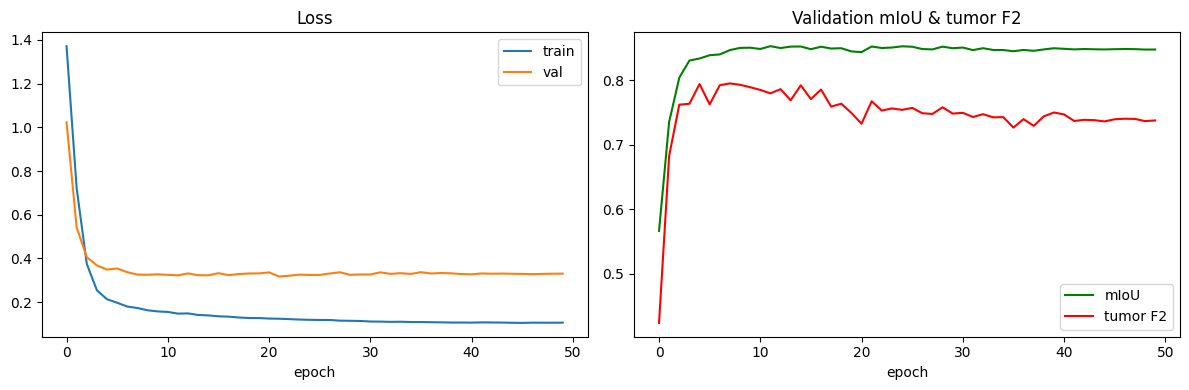

In [8]:
# =====================================================================
# 7. Train >=50 epochs with AMP; track best val mIoU; plot curves
# =====================================================================
opt = torch.optim.AdamW(model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])
warmup = 3
sched = torch.optim.lr_scheduler.SequentialLR(opt, [
    torch.optim.lr_scheduler.LinearLR(opt, 0.1, 1.0, total_iters=warmup),
    torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=CONFIG["epochs"]-warmup)],
    milestones=[warmup])
scaler = torch.amp.GradScaler(enabled=CONFIG["amp"])

def run_eval(loader):
    model.eval(); cm = ConfMat(NUM_CLASSES); vloss = 0.0
    with torch.no_grad():
        for x, y, _ in loader:
            x, y = x.to(device), y.to(device)
            with torch.amp.autocast(device.type, enabled=CONFIG["amp"]):
                out = forward_logits(x); vloss += criterion(out, y).item()
            cm.update(out.argmax(1).cpu(), y.cpu())
    return vloss/len(loader), cm.compute(), cm

hist = {"train_loss": [], "val_loss": [], "val_miou": [], "val_tumor_f2": []}
best_f2, best_miou, t0 = -1.0, -1.0, time.time()
for ep in range(1, CONFIG["epochs"]+1):
    model.train(); tl = 0.0
    for bi, (x, y, _) in enumerate(train_loader):
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        with torch.amp.autocast(device.type, enabled=CONFIG["amp"]):
            loss = criterion(forward_logits(x), y)
        scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        tl += loss.item()
        if (bi+1) % 200 == 0: print(f"  ep{ep} it{bi+1}/{len(train_loader)} loss {loss.item():.3f}")
    sched.step()
    vloss, vm, vcm = run_eval(val_loader)
    f2, rec, prec = tumor_f2_from_cm(vcm)
    hist["train_loss"].append(tl/len(train_loader)); hist["val_loss"].append(vloss)
    hist["val_miou"].append(vm["miou"]); hist["val_tumor_f2"].append(f2)
    best_miou = max(best_miou, vm["miou"])
    print(f"epoch {ep:02d}/{CONFIG['epochs']} | train {tl/len(train_loader):.3f} | val {vloss:.3f} | "
          f"mIoU {vm['miou']:.4f} | tumorF2 {f2:.4f} (R {rec:.3f} P {prec:.3f})")
    if f2 > best_f2:                               # SELECT BY TUMOR F2 (recall-weighted)
        best_f2 = f2; torch.save(model.state_dict(), WORK/"segformer_best.pt")
train_time = time.time()-t0
print(f"\nDONE in {train_time/60:.1f} min | best val tumor F2 {best_f2:.4f} | best val mIoU {best_miou:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(hist["train_loss"], label="train"); ax[0].plot(hist["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(hist["val_miou"], color="green", label="mIoU"); ax[1].plot(hist["val_tumor_f2"], color="red", label="tumor F2")
ax[1].set_title("Validation mIoU & tumor F2"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.savefig(WORK/"segformer_curves.png", dpi=120); plt.show()

## 8. Test-set evaluation (Task F)

=== SegFormer-B0 — TEST metrics ===
     class    IoU   Dice
background 0.9920 0.9960
     liver 0.8853 0.9392
     tumor 0.3806 0.5514

mIoU 0.7526 | mean Dice 0.8288 | pixel acc 0.9908 | mean pixel acc 0.7915

--- CLINICAL METRICS (medical-grade) ---
tumor sensitivity (recall) : 0.4060   (miss rate 59.4%)  <- key clinical number
liver sensitivity (recall) : 0.9745
per-patient liver Dice     : 0.9377 +/- 0.0334  (n=19 volumes)
per-patient tumor Dice     : 0.4595 +/- 0.3186  (n=16 volumes)


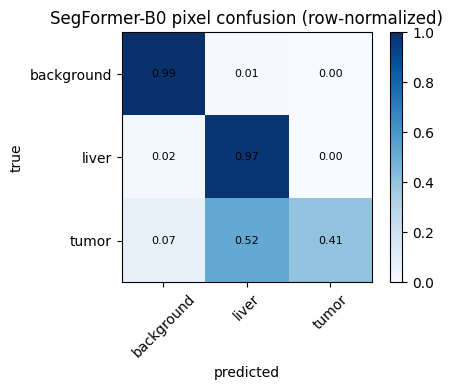

In [9]:
# =====================================================================
# 8. Task F — held-out test metrics + confusion matrix
# =====================================================================
from collections import defaultdict
model.load_state_dict(torch.load(WORK/"segformer_best.pt", map_location=device))

def tta_pred(x):   # horizontal-flip test-time augmentation (free recall/Dice bump)
    with torch.amp.autocast(device.type, enabled=CONFIG["amp"]):
        o1 = forward_logits(x).softmax(1)
        o2 = torch.flip(forward_logits(torch.flip(x, dims=[3])).softmax(1), dims=[3])
    return (o1 + o2).argmax(1).cpu()

cmref = ConfMat(NUM_CLASSES); vol_cms = defaultdict(lambda: ConfMat(NUM_CLASSES)); model.eval()
with torch.no_grad():
    for x, y, keys in test_loader:
        p = tta_pred(x.to(device))
        cmref.update(p, y)
        for b, key in enumerate(keys):
            vol_cms[int(key.split("_")[0])].update(p[b], y[b])
testm = cmref.compute()

def _dice_c(cm, c):
    m=cm.mat.double(); tp=m[c,c]; fp=m[:,c].sum()-tp; fn=m[c,:].sum()-tp
    return (2*tp/(2*tp+fp+fn).clamp(min=1e-9)).item()
def _sens_c(cm, c):
    m=cm.mat.double(); tp=m[c,c]; fn=m[c,:].sum()-tp
    return (tp/(tp+fn).clamp(min=1e-9)).item()
tumor_sens=_sens_c(cmref,2); liver_sens=_sens_c(cmref,1)
liver_vd=[_dice_c(cm,1) for cm in vol_cms.values() if cm.mat[1,:].sum()>0]
tumor_vd=[_dice_c(cm,2) for cm in vol_cms.values() if cm.mat[2,:].sum()>0]
pv_liver=(float(np.mean(liver_vd)), float(np.std(liver_vd)))
pv_tumor=(float(np.mean(tumor_vd)), float(np.std(tumor_vd)))

print("=== SegFormer-B0 — TEST metrics ===")
tbl = pd.DataFrame({"class": CLASS_NAMES,
                    "IoU": np.round(testm["iou"], 4),
                    "Dice": np.round(testm["dice"], 4)})
print(tbl.to_string(index=False))
print(f"\nmIoU {testm['miou']:.4f} | mean Dice {testm['mdice']:.4f} | "
      f"pixel acc {testm['pixel_acc']:.4f} | mean pixel acc {testm['mean_pixel_acc']:.4f}")
print("\n--- CLINICAL METRICS (medical-grade) ---")
print(f"tumor sensitivity (recall) : {tumor_sens:.4f}   (miss rate {1-tumor_sens:.1%})  <- key clinical number")
print(f"liver sensitivity (recall) : {liver_sens:.4f}")
print(f"per-patient liver Dice     : {pv_liver[0]:.4f} +/- {pv_liver[1]:.4f}  (n={len(liver_vd)} volumes)")
print(f"per-patient tumor Dice     : {pv_tumor[0]:.4f} +/- {pv_tumor[1]:.4f}  (n={len(tumor_vd)} volumes)")

cmn = cmref.mat.double(); cmn = (cmn / cmn.sum(1, keepdim=True).clamp(min=1e-9)).numpy()
plt.figure(figsize=(5,4)); plt.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
plt.xticks(range(NUM_CLASSES), CLASS_NAMES, rotation=45); plt.yticks(range(NUM_CLASSES), CLASS_NAMES)
plt.xlabel("predicted"); plt.ylabel("true"); plt.title("SegFormer-B0 pixel confusion (row-normalized)")
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES): plt.text(j, i, f"{cmn[i,j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(); plt.tight_layout(); plt.savefig(WORK/"segformer_confusion.png", dpi=120); plt.show()

## 9. Error analysis (Task G)
Worst-performing test slices by per-image IoU (prediction vs. ground truth) and the most-confused class pair.

**Hypotheses (to confirm against the outputs below):**
- **Tumor is expected to be the hardest class** (~0.4% of pixels, tiny low-contrast lesions, ambiguous boundaries on CT).
- **Tumor <-> liver confusion** likely dominates — lesions sit inside the liver and share intensity ranges.
- SegFormer's transformer receptive field may capture liver context well but **struggle on the smallest tumors** (few tokens); the printed most-confused pair quantifies which error dominates.

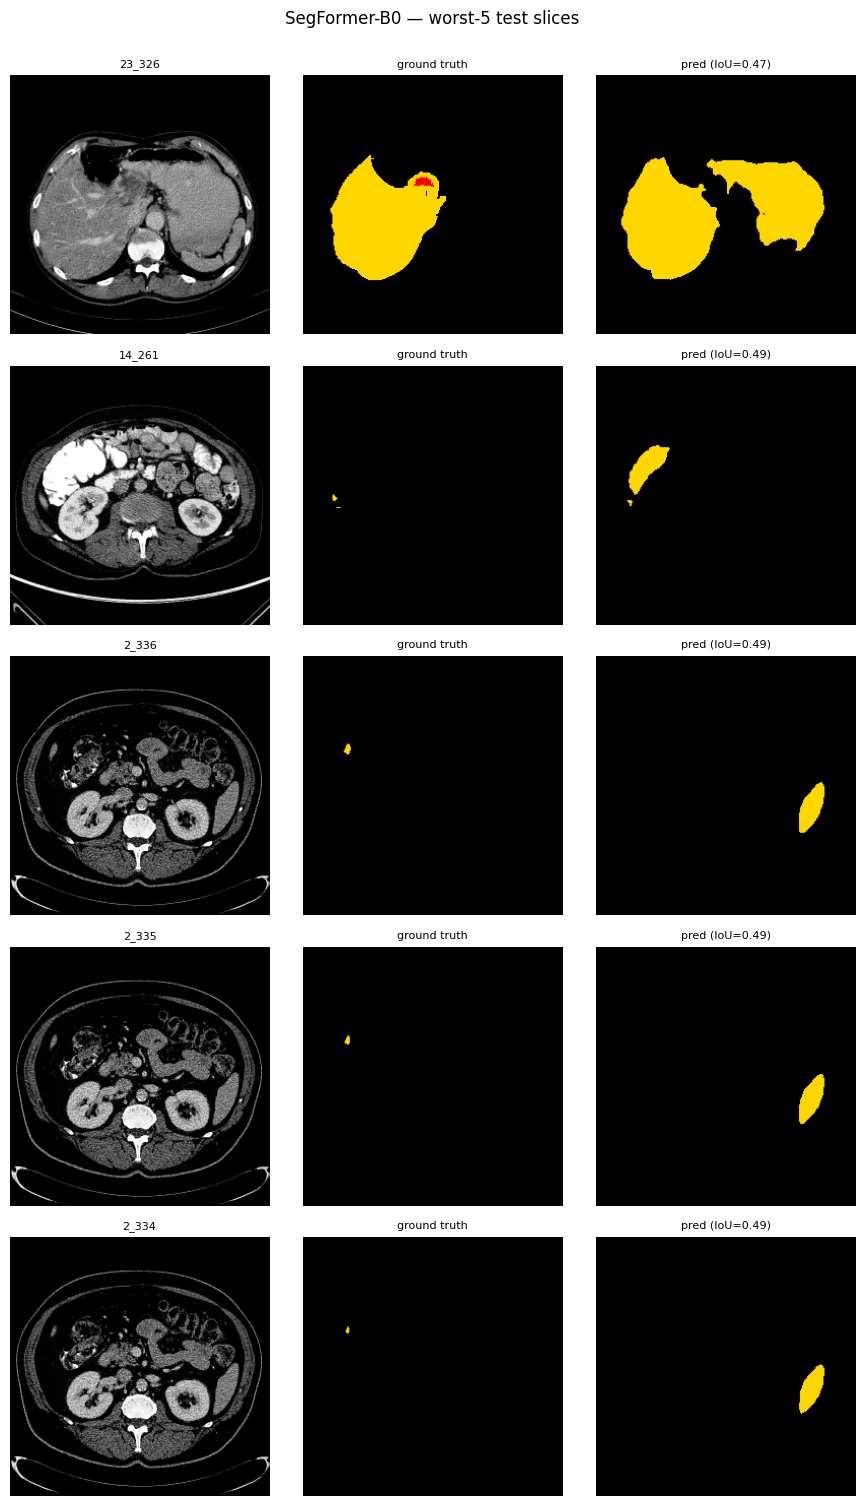

most-confused class pair: TRUE 'background' -> PRED 'liver' (1139549 px)


In [10]:
# =====================================================================
# 9. Task G — worst test images + most-confused class pair
# =====================================================================
def image_iou(pred, tgt):
    ious = []
    for c in range(NUM_CLASSES):
        ti = tgt == c
        if ti.sum() == 0: continue
        pi = pred == c
        inter = (pi & ti).sum().item(); union = (pi | ti).sum().item()
        ious.append(inter/union if union else 0.0)
    return float(np.mean(ious)) if ious else 1.0

scores = []; model.eval()
with torch.no_grad():
    for i in range(len(test_ds)):
        x, y, key = test_ds[i]
        with torch.amp.autocast(device.type, enabled=CONFIG["amp"]):
            p = forward_logits(x.unsqueeze(0).to(device)).argmax(1)[0].cpu()
        scores.append((image_iou(p, y), key, p, y))
scores.sort(key=lambda t: t[0])

cmap = plt.matplotlib.colors.ListedColormap(["black","gold","red"])
worst = scores[:5]
fig, ax = plt.subplots(len(worst), 3, figsize=(9, 3*len(worst)))
for i, (sc, key, p, y) in enumerate(worst):
    k = tuple(int(v) for v in key.split("_")); im = np.array(Image.open(img_by[k]).convert("L"))
    ax[i,0].imshow(im, cmap="gray"); ax[i,0].set_title(f"{key}", fontsize=8)
    ax[i,1].imshow(y.numpy(), cmap=cmap, vmin=0, vmax=2); ax[i,1].set_title("ground truth", fontsize=8)
    ax[i,2].imshow(p.numpy(), cmap=cmap, vmin=0, vmax=2); ax[i,2].set_title(f"pred (IoU={sc:.2f})", fontsize=8)
    for j in range(3): ax[i,j].axis("off")
plt.suptitle("SegFormer-B0 — worst-5 test slices", y=1.001)
plt.tight_layout(); plt.savefig(WORK/"segformer_worst.png", dpi=120); plt.show()

off = cmref.mat.clone(); off.fill_diagonal_(0)
a, b = np.unravel_index(off.numpy().argmax(), off.shape)
print(f"most-confused class pair: TRUE '{CLASS_NAMES[a]}' -> PRED '{CLASS_NAMES[b]}' ({off[a,b].item()} px)")

## 10. Summary — append to shared `results.json` (for NB3 Task H)

In [11]:
# =====================================================================
# 10. Save results for the final 3-model comparison (Task H in NB3)
# =====================================================================
res_path = WORK/"results.json"
res = json.load(open(res_path)) if res_path.exists() else {}
res["SegFormer-B0"] = {
    "miou": testm["miou"], "iou_per_class": testm["iou"],
    "dice": testm["mdice"], "dice_per_class": testm["dice"],
    "pixel_acc": testm["pixel_acc"], "mean_pixel_acc": testm["mean_pixel_acc"],
    "tumor_sensitivity": tumor_sens, "liver_sensitivity": liver_sens,
    "pv_liver_dice": pv_liver, "pv_tumor_dice": pv_tumor,
    "class_names": CLASS_NAMES, "best_val_miou": best_miou, "best_val_tumor_f2": best_f2,
    "train_time_min": round(train_time/60, 1), "config": CONFIG,
}
json.dump(res, open(res_path, "w"), indent=2)
print("saved -> results.json  (models:", list(res.keys()), ")")

from IPython.display import Markdown, display
display(Markdown(f"""### SegFormer-B0 — results summary
| metric | background | liver | tumor | mean |
|---|---|---|---|---|
| IoU  | {testm['iou'][0]:.3f} | {testm['iou'][1]:.3f} | {testm['iou'][2]:.3f} | **{testm['miou']:.3f}** |
| Dice | {testm['dice'][0]:.3f} | {testm['dice'][1]:.3f} | {testm['dice'][2]:.3f} | **{testm['mdice']:.3f}** |

- **Overall pixel accuracy:** {testm['pixel_acc']:.3f} | **mean pixel accuracy:** {testm['mean_pixel_acc']:.3f}
- **Best val mIoU:** {best_miou:.3f} | **training time:** {train_time/60:.1f} min
- Metrics appended to `results.json` for the NB3 Task H comparison."""))

saved -> results.json  (models: ['SegFormer-B0'] )


### SegFormer-B0 — results summary
| metric | background | liver | tumor | mean |
|---|---|---|---|---|
| IoU  | 0.992 | 0.885 | 0.381 | **0.753** |
| Dice | 0.996 | 0.939 | 0.551 | **0.829** |

- **Overall pixel accuracy:** 0.991 | **mean pixel accuracy:** 0.791
- **Best val mIoU:** 0.853 | **training time:** 105.4 min
- Metrics appended to `results.json` for the NB3 Task H comparison.

## References (Academic Integrity)
- HuggingFace, *SegFormer model documentation*. https://huggingface.co/docs/transformers/model_doc/segformer
- Xie et al., *SegFormer: Simple and Efficient Design for Semantic Segmentation with Transformers*, NeurIPS 2021.
- Albumentations, *Synchronized image & mask transforms*. https://albumentations.ai/docs/
All model/pipeline code is our own; official documentation is cited where its APIs were used.